In [1]:
!apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import matplotlib as mpl

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)

plt.rc("font", family="NanumGothic")
plt.rc("axes", unicode_minus=False)

print("현재 폰트 설정:", mpl.rcParams["font.family"])

현재 폰트 설정: ['NanumGothic']


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("/content/drive/MyDrive/baram2026/open")
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

TARGET_COLS = ["kpx_group_1", "kpx_group_2", "kpx_group_3"]
CAPACITY_KWH = {"kpx_group_1": 21600, "kpx_group_2": 21600, "kpx_group_3": 21000}

In [4]:
train_labels = pd.read_csv(TRAIN_DIR / "train_labels.csv", encoding="utf-8-sig")
train_labels["kst_dtm"] = pd.to_datetime(train_labels["kst_dtm"])

ldaps_train = pd.read_csv(TRAIN_DIR / "ldaps_train.csv", encoding="utf-8-sig")
gfs_train = pd.read_csv(TRAIN_DIR / "gfs_train.csv", encoding="utf-8-sig")

scada_vestas = pd.read_csv(TRAIN_DIR / "scada_vestas_train.csv", encoding="utf-8-sig")
scada_unison = pd.read_csv(TRAIN_DIR / "scada_unison_train.csv", encoding="utf-8-sig")
scada_vestas["kst_dtm"] = pd.to_datetime(scada_vestas["kst_dtm"])
scada_unison["kst_dtm"] = pd.to_datetime(scada_unison["kst_dtm"])

print("train_labels:", train_labels.shape)
print("ldaps_train:", ldaps_train.shape, " gfs_train:", gfs_train.shape)
print("scada_vestas:", scada_vestas.shape, " scada_unison:", scada_unison.shape)

train_labels: (26304, 4)
ldaps_train: (420864, 35)  gfs_train: (236736, 40)
scada_vestas: (157819, 37)  scada_unison: (105264, 16)


In [5]:
def aggregate_weather(df, prefix):
    df = df.copy()
    df["forecast_kst_dtm"] = pd.to_datetime(df["forecast_kst_dtm"])
    df["data_available_kst_dtm"] = pd.to_datetime(df["data_available_kst_dtm"])

    drop_cols = {"data_available_kst_dtm", "grid_id", "latitude", "longitude"}
    value_cols = [c for c in df.columns if c not in {"forecast_kst_dtm", *drop_cols}]

    agg_mean = df.groupby("forecast_kst_dtm")[value_cols].mean()
    agg_mean.columns = [f"{prefix}_{c}_mean" for c in agg_mean.columns]

    agg_std = df.groupby("forecast_kst_dtm")[value_cols].std()
    agg_std.columns = [f"{prefix}_{c}_std" for c in agg_std.columns]

    lead = df.groupby("forecast_kst_dtm").agg(data_available_kst_dtm=("data_available_kst_dtm", "first"))
    lead[f"{prefix}_lead_hours"] = (lead.index - lead["data_available_kst_dtm"]).dt.total_seconds() / 3600
    lead = lead[[f"{prefix}_lead_hours"]]

    return agg_mean.join(agg_std).join(lead).reset_index()


ldaps_agg = aggregate_weather(ldaps_train, "ldaps")
gfs_agg = aggregate_weather(gfs_train, "gfs")

weather = ldaps_agg.merge(gfs_agg, on="forecast_kst_dtm", how="inner")
df = train_labels.rename(columns={"kst_dtm": "forecast_kst_dtm"}).merge(
    weather, on="forecast_kst_dtm", how="left"
)

print("병합된 df:", df.shape)
df.head()

병합된 df: (26304, 136)


,forecast_kst_dtm,kpx_group_1,kpx_group_2,kpx_group_3,ldaps_heightAboveGround_10_10u_mean,ldaps_heightAboveGround_10_10v_mean,ldaps_heightAboveGround_50_50MUmax_mean,ldaps_heightAboveGround_50_50MUmin_mean,ldaps_heightAboveGround_50_50MVmax_mean,ldaps_heightAboveGround_50_50MVmin_mean,...,gfs_isobaricInhPa_850_v_std,gfs_isobaricInhPa_850_r_std,gfs_isobaricInhPa_700_t_std,gfs_isobaricInhPa_700_u_std,gfs_isobaricInhPa_700_v_std,gfs_isobaricInhPa_500_gh_std,gfs_isobaricInhPa_500_t_std,gfs_isobaricInhPa_500_u_std,gfs_isobaricInhPa_500_v_std,gfs_lead_hours
0,2022-01-01 01:00:00,12004.421,9719.242,NaN,5.297585,-0.173397,8.421367,7.729351,0.158442,-0.198080,...,1.707416,0.650214,0.574630,0.364387,0.380986,6.881510,0.251137,0.830663,0.979087,12.0
1,2022-01-01 02:00:00,12901.137,10297.768,NaN,4.346036,-0.407328,8.261779,6.641635,0.045467,-0.761471,...,1.602592,0.493570,0.422511,0.282007,0.575879,5.978090,0.527742,1.258747,0.813088,13.0
2,2022-01-01 03:00:00,12091.200,10731.663,NaN,4.191131,-0.210821,6.637347,5.875278,-0.297825,-0.642738,...,1.779080,0.617342,0.309461,0.227181,0.734072,5.454841,0.499762,1.447795,0.675977,14.0
3,2022-01-01 04:00:00,17167.768,13841.242,NaN,4.471477,0.146902,6.446555,6.008483,0.107107,-0.313108,...,1.861747,0.635304,0.303942,0.230567,0.787130,5.145795,0.331932,1.086022,0.529150,15.0
4,2022-01-01 05:00:00,19134.758,14014.800,NaN,4.264158,0.126001,6.422876,5.993835,0.148190,0.057693,...,1.867793,0.526783,0.393693,0.378003,0.774991,4.982051,0.285461,0.975677,0.603692,16.0


In [6]:
check_cols = [c for c in df.columns if c.endswith("_std") or c.endswith("_lead_hours")]
for target in TARGET_COLS:
    sub_t = df.dropna(subset=[target])
    print(f"[{target}]")
    corrs = []
    for c in check_cols:
        corr = sub_t[[c, target]].corr().iloc[0, 1]
        corrs.append((c, corr))
    for c, corr in sorted(corrs, key=lambda x: -abs(x[1]))[:8]:
        print(f"  {c}: corr={corr:.3f}")
    print()

weather_cols = [c for c in df.columns if c.startswith(("ldaps_", "gfs_"))]
print(df[weather_cols].isna().mean().sort_values(ascending=False).head(10))

[kpx_group_1]
  ldaps_heightAboveGround_5_YBLWS_std: corr=0.668
  ldaps_meanSea_0_prmsl_std: corr=0.572
  ldaps_heightAboveGround_50_50MUmax_std: corr=0.553
  ldaps_heightAboveGround_50_50MUmin_std: corr=0.537
  ldaps_heightAboveGround_50_50MVmax_std: corr=0.440
  ldaps_heightAboveGround_50_50MVmin_std: corr=0.424
  ldaps_heightAboveGround_10_10v_std: corr=0.401
  ldaps_heightAboveGround_10_10u_std: corr=0.400

[kpx_group_2]
  ldaps_heightAboveGround_5_YBLWS_std: corr=0.673
  ldaps_meanSea_0_prmsl_std: corr=0.581
  ldaps_heightAboveGround_50_50MUmax_std: corr=0.545
  ldaps_heightAboveGround_50_50MUmin_std: corr=0.530
  ldaps_heightAboveGround_50_50MVmax_std: corr=0.429
  ldaps_heightAboveGround_50_50MVmin_std: corr=0.414
  ldaps_heightAboveGround_10_10u_std: corr=0.391
  ldaps_heightAboveGround_10_10v_std: corr=0.385

[kpx_group_3]
  ldaps_heightAboveGround_5_YBLWS_std: corr=0.658
  ldaps_meanSea_0_prmsl_std: corr=0.558
  ldaps_heightAboveGround_50_50MUmax_std: corr=0.494
  ldaps_heigh

In [7]:
wind_cols = [c for c in df.columns if re.search(r"(10u|10v|80_u|80_v|100u|100v)", c)]
print("바람 관련 컬럼:")
for c in wind_cols:
    print(" ", c)

바람 관련 컬럼:
  ldaps_heightAboveGround_10_10u_mean
  ldaps_heightAboveGround_10_10v_mean
  ldaps_heightAboveGround_10_10u_std
  ldaps_heightAboveGround_10_10v_std
  gfs_heightAboveGround_10_10u_mean
  gfs_heightAboveGround_10_10v_mean
  gfs_heightAboveGround_80_u_mean
  gfs_heightAboveGround_80_v_mean
  gfs_heightAboveGround_100_100u_mean
  gfs_heightAboveGround_100_100v_mean
  gfs_heightAboveGround_10_10u_std
  gfs_heightAboveGround_10_10v_std
  gfs_heightAboveGround_80_u_std
  gfs_heightAboveGround_80_v_std
  gfs_heightAboveGround_100_100u_std
  gfs_heightAboveGround_100_100v_std


In [8]:
weather_value_cols = [c for c in df.columns if c.startswith(("ldaps_", "gfs_")) and c.endswith("_mean")]
desc = df[weather_value_cols].describe().T
desc["range_check"] = desc["max"] - desc["min"]
display(desc.sort_values("range_check", ascending=False).head(15))

,count,mean,std,min,25%,50%,75%,max,range_check
gfs_planetaryBoundaryLayer_0_VRATE_mean,26304.0,3497.899927,5999.673251,0.000000,155.555556,1000.000000,3888.888889,58777.777778,58777.777778
ldaps_meanSea_0_prmsl_mean,26304.0,101454.270116,760.681872,98112.259375,100869.989859,101513.225500,102027.139141,103381.528250,5269.268875
gfs_meanSea_0_prmsl_mean,26304.0,101635.377559,781.044697,98882.016667,101018.652583,101659.629222,102232.185722,103661.964444,4779.947778
ldaps_surface_0_sp_mean,26304.0,90673.491864,523.593541,88054.028750,90315.526875,90705.481250,91041.982500,92219.286250,4165.257500
gfs_surface_0_sp_mean,26304.0,95444.077042,611.914099,93030.838889,94992.354000,95484.445889,95883.302056,97135.316889,4104.478000
ldaps_etc_0_blh_mean,26304.0,340.230303,278.551502,37.879624,156.922524,227.128592,435.125247,2916.235250,2878.355626
ldaps_surface_0_NDNSW_mean,26304.0,151.796905,230.035333,0.000000,0.000000,6.165344,246.879708,935.315920,935.315920
gfs_surface_0_dswrf_mean,26304.0,179.505842,242.165557,0.000000,0.000000,43.694444,315.941111,933.201778,933.201778
ldaps_heightAboveGround_2_SWDIR_mean,26304.0,120.160059,214.190707,0.000000,0.000000,0.006882,149.072998,931.444341,931.444341
gfs_isobaricInhPa_500_gh_mean,26304.0,5662.886423,159.030578,5058.373889,5543.896975,5680.626867,5798.995867,5971.371244,912.997356


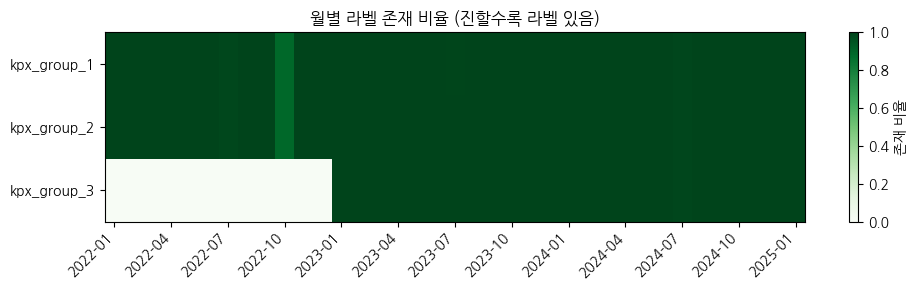

In [9]:
avail = df.set_index("forecast_kst_dtm")[TARGET_COLS].notna().resample("ME").mean()

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(avail.T, aspect="auto", cmap="Greens", vmin=0, vmax=1)
ax.set_yticks(range(len(TARGET_COLS)))
ax.set_yticklabels(TARGET_COLS)
ax.set_xticks(range(0, len(avail), 3))
ax.set_xticklabels([d.strftime("%Y-%m") for d in avail.index[::3]], rotation=45, ha="right")
ax.set_title("월별 라벨 존재 비율 (진할수록 라벨 있음)")
plt.colorbar(im, ax=ax, label="존재 비율")
plt.tight_layout()
plt.show()

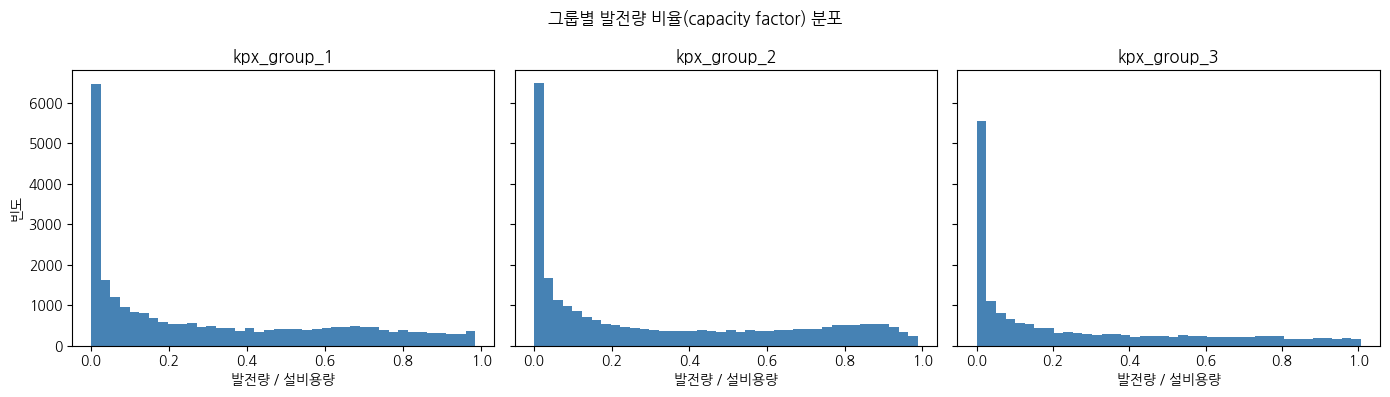

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, col in zip(axes, TARGET_COLS):
    ratio = df[col].dropna() / CAPACITY_KWH[col]
    ax.hist(ratio, bins=40, color="steelblue")
    ax.set_title(col)
    ax.set_xlabel("발전량 / 설비용량")
axes[0].set_ylabel("빈도")
plt.suptitle("그룹별 발전량 비율(capacity factor) 분포")
plt.tight_layout()
plt.show()

In [11]:
wind_speed_cols = {}

if {"gfs_heightAboveGround_10_10u_mean", "gfs_heightAboveGround_10_10v_mean"}.issubset(df.columns):
    df["gfs_ws_10m"] = np.sqrt(df["gfs_heightAboveGround_10_10u_mean"] ** 2 + df["gfs_heightAboveGround_10_10v_mean"] ** 2)
    wind_speed_cols["GFS 10m"] = "gfs_ws_10m"

if {"gfs_heightAboveGround_80_u_mean", "gfs_heightAboveGround_80_v_mean"}.issubset(df.columns):
    df["gfs_ws_80m"] = np.sqrt(df["gfs_heightAboveGround_80_u_mean"] ** 2 + df["gfs_heightAboveGround_80_v_mean"] ** 2)
    wind_speed_cols["GFS 80m"] = "gfs_ws_80m"

if {"gfs_heightAboveGround_100_100u_mean", "gfs_heightAboveGround_100_100v_mean"}.issubset(df.columns):
    df["gfs_ws_100m"] = np.sqrt(df["gfs_heightAboveGround_100_100u_mean"] ** 2 + df["gfs_heightAboveGround_100_100v_mean"] ** 2)
    wind_speed_cols["GFS 100m"] = "gfs_ws_100m"

if {"ldaps_heightAboveGround_10_10u_mean", "ldaps_heightAboveGround_10_10v_mean"}.issubset(df.columns):
    df["ldaps_ws_10m"] = np.sqrt(df["ldaps_heightAboveGround_10_10u_mean"] ** 2 + df["ldaps_heightAboveGround_10_10v_mean"] ** 2)
    wind_speed_cols["LDAPS 10m"] = "ldaps_ws_10m"

print("생성된 풍속 컬럼:", wind_speed_cols)

생성된 풍속 컬럼: {'GFS 10m': 'gfs_ws_10m', 'GFS 80m': 'gfs_ws_80m', 'GFS 100m': 'gfs_ws_100m', 'LDAPS 10m': 'ldaps_ws_10m'}


In [12]:
ldaps_50_cols = [c for c in df.columns if "50M" in c]
print("LDAPS 50m 관련 컬럼:", ldaps_50_cols)

for target in TARGET_COLS:
    sub_t = df.dropna(subset=[target])
    for c in ldaps_50_cols:
        corr = sub_t[[c, target]].corr().iloc[0, 1]
        print(f"{target} vs {c}: corr={corr:.3f}")

LDAPS 50m 관련 컬럼: ['ldaps_heightAboveGround_50_50MUmax_mean', 'ldaps_heightAboveGround_50_50MUmin_mean', 'ldaps_heightAboveGround_50_50MVmax_mean', 'ldaps_heightAboveGround_50_50MVmin_mean', 'ldaps_heightAboveGround_50_50MUmax_std', 'ldaps_heightAboveGround_50_50MUmin_std', 'ldaps_heightAboveGround_50_50MVmax_std', 'ldaps_heightAboveGround_50_50MVmin_std']
kpx_group_1 vs ldaps_heightAboveGround_50_50MUmax_mean: corr=0.681
kpx_group_1 vs ldaps_heightAboveGround_50_50MUmin_mean: corr=0.685
kpx_group_1 vs ldaps_heightAboveGround_50_50MVmax_mean: corr=0.270
kpx_group_1 vs ldaps_heightAboveGround_50_50MVmin_mean: corr=0.296
kpx_group_1 vs ldaps_heightAboveGround_50_50MUmax_std: corr=0.553
kpx_group_1 vs ldaps_heightAboveGround_50_50MUmin_std: corr=0.537
kpx_group_1 vs ldaps_heightAboveGround_50_50MVmax_std: corr=0.440
kpx_group_1 vs ldaps_heightAboveGround_50_50MVmin_std: corr=0.424
kpx_group_2 vs ldaps_heightAboveGround_50_50MUmax_mean: corr=0.671
kpx_group_2 vs ldaps_heightAboveGround_50_5

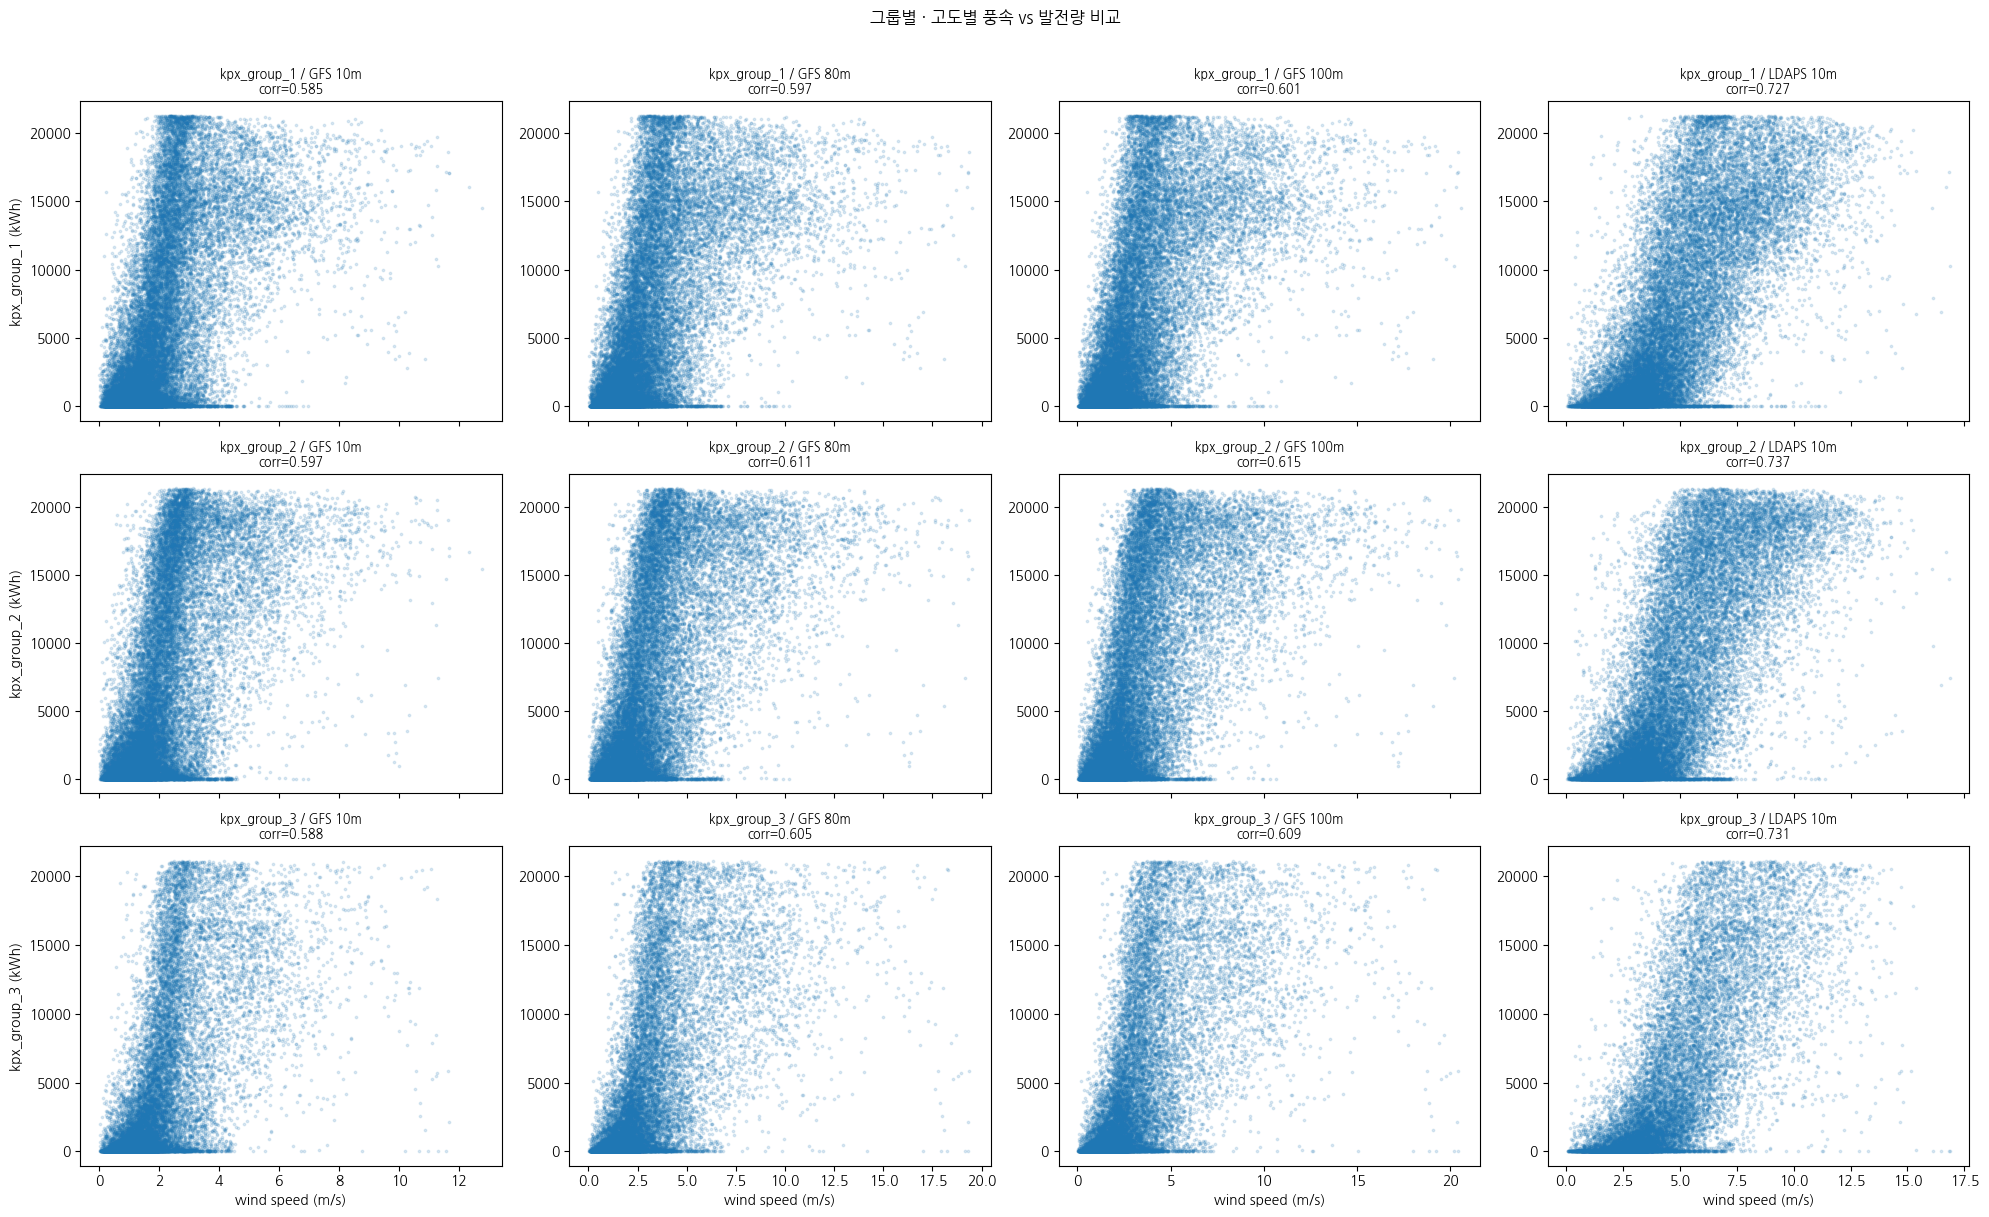

In [13]:
fig, axes = plt.subplots(
    len(TARGET_COLS), len(wind_speed_cols),
    figsize=(5 * len(wind_speed_cols), 4 * len(TARGET_COLS)),
    sharex="col"
)

for row, target in enumerate(TARGET_COLS):
    sub_t = df.dropna(subset=[target])
    for col_idx, (label, col) in enumerate(wind_speed_cols.items()):
        ax = axes[row, col_idx]
        corr = sub_t[[col, target]].corr().iloc[0, 1]
        ax.scatter(sub_t[col], sub_t[target], s=3, alpha=0.15)
        ax.set_title(f"{target} / {label}\ncorr={corr:.3f}", fontsize=9)
        if row == len(TARGET_COLS) - 1:
            ax.set_xlabel("wind speed (m/s)")
    axes[row, 0].set_ylabel(f"{target} (kWh)")

plt.suptitle("그룹별 · 고도별 풍속 vs 발전량 비교", y=1.01)
plt.tight_layout()
plt.show()

=== kpx_group_1 : 구간별 평균 발전량 ===
season                      겨울           봄가을            여름
ws_bin                                                    
(0.0169, 1.156]     629.147356    845.550390    717.569870
(1.156, 2.277]     1034.830630    939.018721    988.925078
(2.277, 3.399]     2268.255165   1919.950168   1518.527945
(3.399, 4.521]     5446.518500   4576.824204   3978.502536
(4.521, 5.643]     9481.666127   7210.188309   6918.647156
(5.643, 6.765]    11989.546274  10896.726808   9190.681757
(6.765, 7.887]    13320.548384  12647.983925  10993.132903
(7.887, 9.009]    14886.098141  14380.673113  12879.471421
(9.009, 10.13]    15644.534933  15309.023058  14508.253282
(10.13, 11.252]   15562.593996  16417.948667  15151.032011
(11.252, 12.374]  15334.119105  17674.500144  14704.899214
(12.374, 13.496]  15203.189417  16283.575598  16785.398625
(13.496, 14.618]   8363.837571  16247.636048  14873.911400
(14.618, 15.74]    2820.316000  16106.698364           NaN
(15.74, 16.862]        

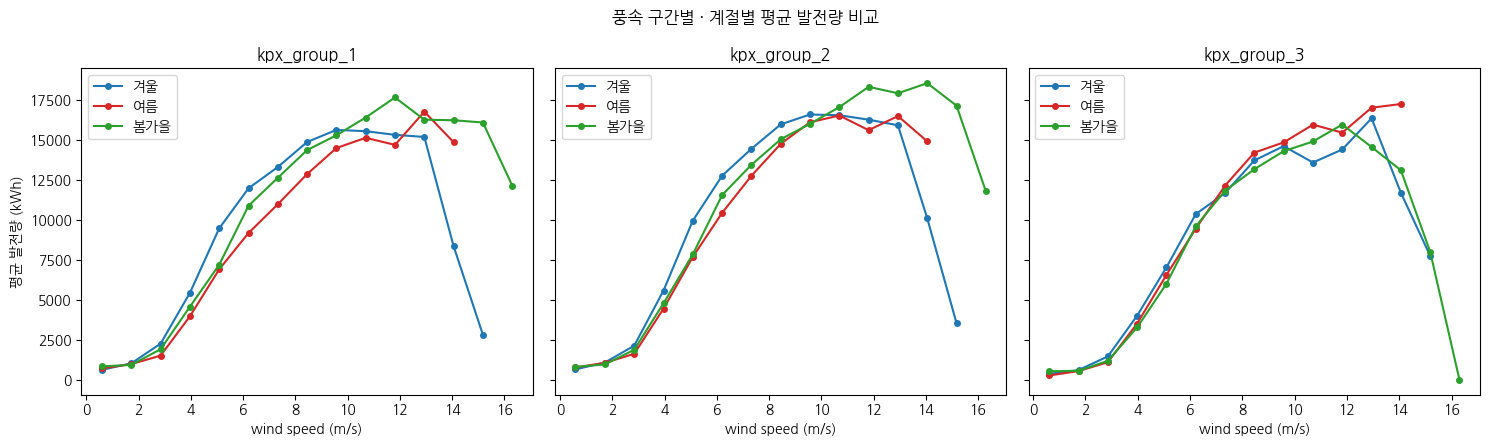

In [14]:
df["season"] = df["forecast_kst_dtm"].dt.month.map(
    lambda m: "겨울" if m in [12, 1, 2] else "여름" if m in [6, 7, 8] else "봄가을"
)

best_ws_col = "ldaps_ws_10m"

fig, axes = plt.subplots(1, len(TARGET_COLS), figsize=(15, 4.5), sharey=True)

for ax, target in zip(axes, TARGET_COLS):
    sub_t = df.dropna(subset=[target, best_ws_col]).copy()
    sub_t["ws_bin"] = pd.cut(sub_t[best_ws_col], bins=15)

    season_pivot = sub_t.groupby(["ws_bin", "season"], observed=True)[target].mean().unstack()
    count_pivot = sub_t.groupby(["ws_bin", "season"], observed=True)[target].count().unstack()

    print(f"=== {target} : 구간별 평균 발전량 ===")
    print(season_pivot)
    print(f"\n=== {target} : 구간별 표본 수 ===")
    print(count_pivot)
    print("\n")

    bin_centers = [interval.mid for interval in season_pivot.index]
    for season, color in zip(["겨울", "여름", "봄가을"], ["tab:blue", "tab:red", "tab:green"]):
        if season in season_pivot.columns:
            ax.plot(bin_centers, season_pivot[season], marker="o", markersize=4, label=season, color=color)

    ax.set_title(target)
    ax.set_xlabel("wind speed (m/s)")
    ax.legend()

axes[0].set_ylabel("평균 발전량 (kWh)")
plt.suptitle("풍속 구간별 · 계절별 평균 발전량 비교")
plt.tight_layout()
plt.show()

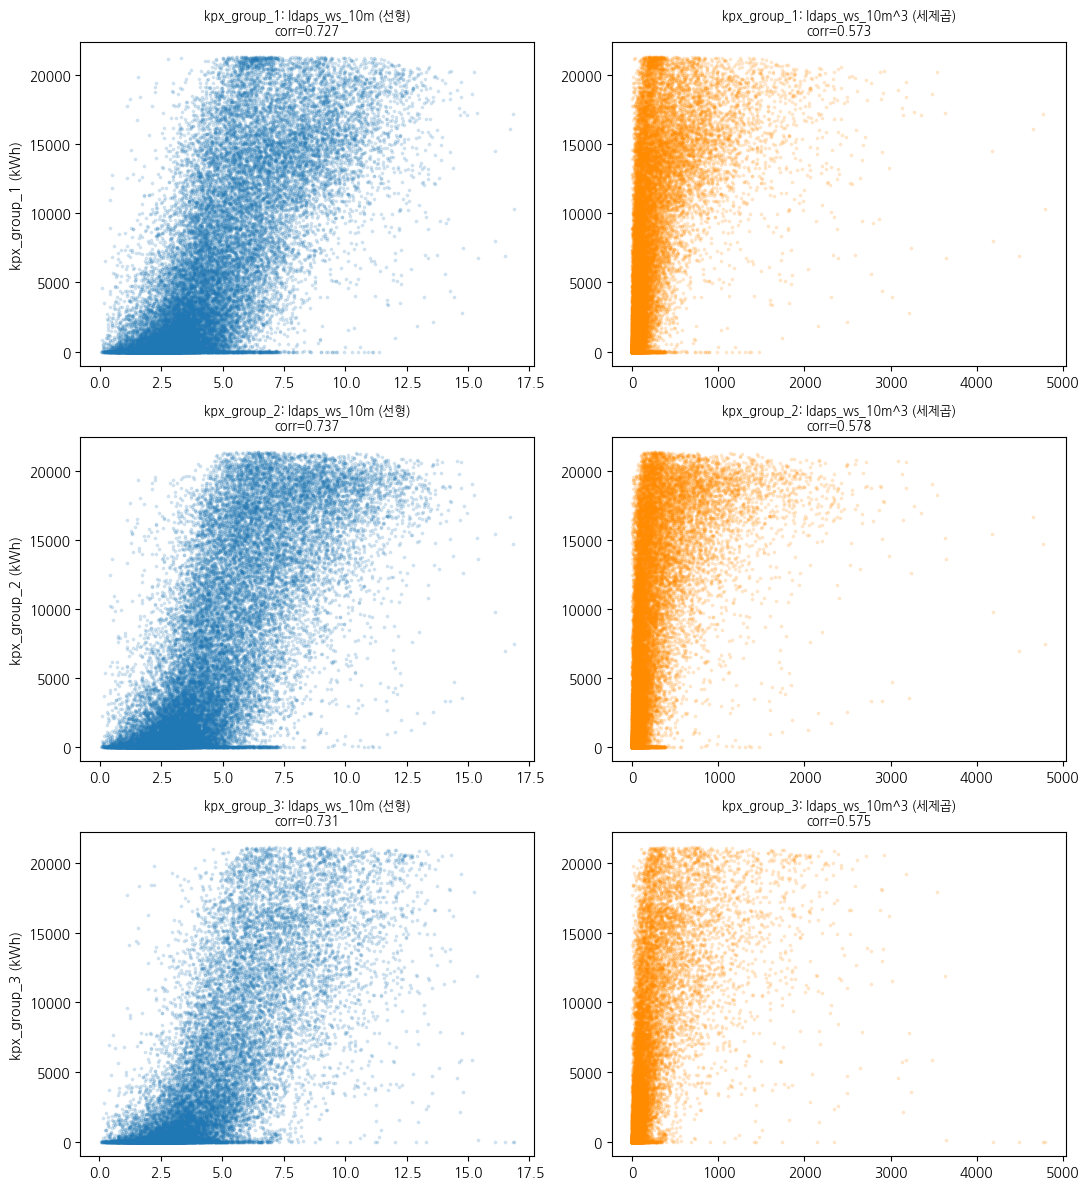

In [15]:
fig, axes = plt.subplots(len(TARGET_COLS), 2, figsize=(11, 4 * len(TARGET_COLS)))

for row, target in enumerate(TARGET_COLS):
    sub_t = df.dropna(subset=[target]).copy()

    corrs = {col: sub_t[[col, target]].corr().iloc[0, 1] for col in wind_speed_cols.values()}
    best_col = max(corrs, key=corrs.get)
    sub_t["ws_cubed"] = sub_t[best_col] ** 3

    axes[row, 0].scatter(sub_t[best_col], sub_t[target], s=3, alpha=0.15)
    axes[row, 0].set_title(f"{target}: {best_col} (선형)\ncorr={corrs[best_col]:.3f}", fontsize=9)
    axes[row, 0].set_ylabel(f"{target} (kWh)")

    cube_corr = sub_t[["ws_cubed", target]].corr().iloc[0, 1]
    axes[row, 1].scatter(sub_t["ws_cubed"], sub_t[target], s=3, alpha=0.15, color="darkorange")
    axes[row, 1].set_title(f"{target}: {best_col}^3 (세제곱)\ncorr={cube_corr:.3f}", fontsize=9)

plt.tight_layout()
plt.show()

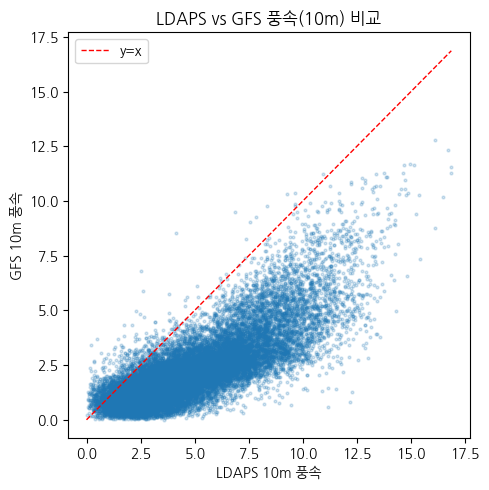

두 소스 풍속 차이(절대값) 평균: 2.578 m/s
두 소스 풍속 차이(절대값) 90분위: 4.683 m/s


In [16]:
if "ldaps_ws_10m" in df.columns and "gfs_ws_10m" in df.columns:
    comp = df.dropna(subset=["ldaps_ws_10m", "gfs_ws_10m"])

    plt.figure(figsize=(5, 5))
    plt.scatter(comp["ldaps_ws_10m"], comp["gfs_ws_10m"], s=4, alpha=0.2)
    max_v = max(comp["ldaps_ws_10m"].max(), comp["gfs_ws_10m"].max())
    plt.plot([0, max_v], [0, max_v], color="red", linewidth=1, linestyle="--", label="y=x")
    plt.xlabel("LDAPS 10m 풍속")
    plt.ylabel("GFS 10m 풍속")
    plt.title("LDAPS vs GFS 풍속(10m) 비교")
    plt.legend()
    plt.tight_layout()
    plt.show()

    diff = (comp["ldaps_ws_10m"] - comp["gfs_ws_10m"]).abs()
    print("두 소스 풍속 차이(절대값) 평균:", diff.mean().round(3), "m/s")
    print("두 소스 풍속 차이(절대값) 90분위:", diff.quantile(0.9).round(3), "m/s")
else:
    print("LDAPS/GFS 10m 풍속 컬럼이 없습니다. 셀 5, 8 출력에서 실제 컬럼명을 확인해주세요.")

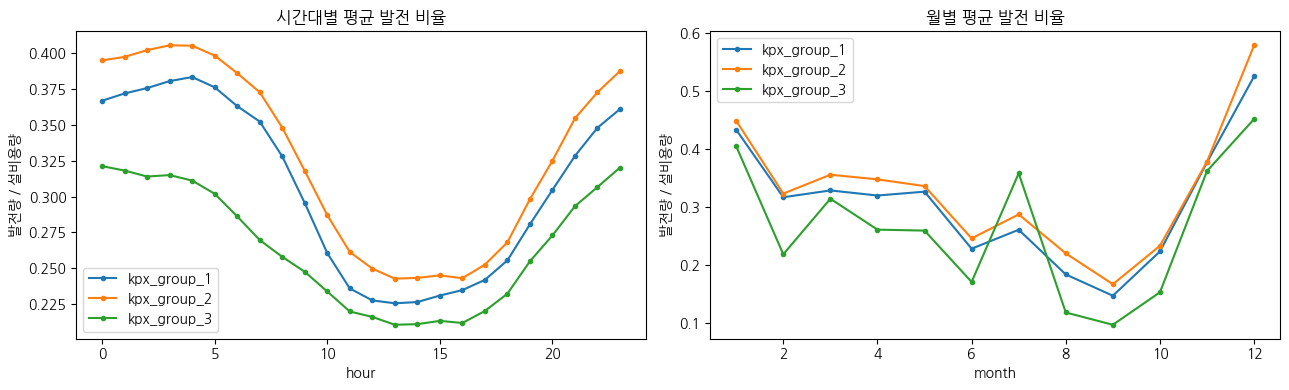

In [17]:
df["hour"] = df["forecast_kst_dtm"].dt.hour
df["month"] = df["forecast_kst_dtm"].dt.month

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for col in TARGET_COLS:
    hourly = df.groupby("hour")[col].mean() / CAPACITY_KWH[col]
    axes[0].plot(hourly.index, hourly.values, marker="o", markersize=3, label=col)

    monthly = df.groupby("month")[col].mean() / CAPACITY_KWH[col]
    axes[1].plot(monthly.index, monthly.values, marker="o", markersize=3, label=col)

axes[0].set_title("시간대별 평균 발전 비율")
axes[0].set_xlabel("hour")
axes[1].set_title("월별 평균 발전 비율")
axes[1].set_xlabel("month")
for ax in axes:
    ax.set_ylabel("발전량 / 설비용량")
    ax.legend()
plt.tight_layout()
plt.show()

In [18]:
def dms_to_decimal(dms_str):
    if pd.isna(dms_str):
        return np.nan, np.nan
    pattern = r"(\d+)\s*[°º]\s*(\d+)\s*[′']\s*([\d.]+)\s*[″\"]\s*([NSEW])"
    matches = re.findall(pattern, dms_str)
    if len(matches) < 2:
        print("매칭 실패:", repr(dms_str))
        return np.nan, np.nan
    lat_d, lat_m, lat_s, lat_dir = matches[0]
    lon_d, lon_m, lon_s, lon_dir = matches[1]
    lat = float(lat_d) + float(lat_m) / 60 + float(lat_s) / 3600
    lon = float(lon_d) + float(lon_m) / 60 + float(lon_s) / 3600
    if lat_dir == "S":
        lat = -lat
    if lon_dir == "W":
        lon = -lon
    return lat, lon


info = pd.read_excel(DATA_DIR / "info.xlsx", header=2)
info.columns = [
    "idx", "단계", "명칭", "제작사", "모델명", "호기",
    "좌표", "KPX그룹", "Hub_Height", "Rotor_Diameter",
    "설비용량_MW", "그룹설비용량_MW",
]
info = info.drop(columns="idx").dropna(subset=["단계"])
info = info[info["단계"] != "단계"]  # ← 추가: 컬럼명이 데이터로 들어간 헛행 제거
info["KPX그룹"] = info["KPX그룹"].ffill()
info["그룹설비용량_MW"] = info["그룹설비용량_MW"].ffill()
info[["lat", "lon"]] = info["좌표"].apply(lambda x: pd.Series(dms_to_decimal(x)))

display(info)

/tmp/ipykernel_1213/2234958942.py:28: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  info["KPX그룹"] = info["KPX그룹"].ffill()
/tmp/ipykernel_1213/2234958942.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  info["그룹설비용량_MW"] = info["그룹설비용량_MW"].ffill()


,단계,명칭,제작사,모델명,호기,좌표,KPX그룹,Hub_Height,Rotor_Diameter,설비용량_MW,그룹설비용량_MW,lat,lon
1,1,태백가덕산,VESTAS,V126,1,"37°16'55.61""N 128°57'02.10""E",1,117,126,3.6,21.6,37.282114,128.950583
2,1,태백가덕산,VESTAS,V126,2,"37°17'04.05""N 128°56'58.35""E",1,117,126,3.6,21.6,37.284458,128.949542
3,1,태백가덕산,VESTAS,V126,3,"37°17'11.49""N 128°56'58.99""E",1,117,126,3.6,21.6,37.286525,128.949719
4,1,태백가덕산,VESTAS,V126,4,"37°17'23.11""N 128°57'03.68""E",1,117,126,3.6,21.6,37.289753,128.951022
5,1,태백가덕산,VESTAS,V126,5,"37°17'28.20""N 128°57'15.58""E",1,117,126,3.6,21.6,37.291167,128.954328
6,1,태백가덕산,VESTAS,V126,6,"37°17'19.48""N 128°57'24.96""E",1,117,126,3.6,21.6,37.288744,128.956933
7,1,태백가덕산,VESTAS,V126,7,"37°17'16.20""N 128°57'34.67""E",2,117,126,3.6,21.6,37.287833,128.959631
8,1,태백가덕산,VESTAS,V126,8,"37°17'11.29""N 128°57'47.24""E",2,117,126,3.6,21.6,37.286469,128.963122
9,1,태백가덕산,VESTAS,V126,9,"37°17'00.97""N 128°57'57.44""E",2,117,126,3.6,21.6,37.283603,128.965956
10,1,태백가덕산,VESTAS,V126,10,"37°16'52.77""N 128°58'04.18""E",2,117,126,3.6,21.6,37.281325,128.967828


In [19]:
group1_turbines = [f"vestas_wtg{i:02d}_power_kw10m" for i in range(1, 7)]
group2_turbines = [f"vestas_wtg{i:02d}_power_kw10m" for i in range(7, 13)]
group3_turbines = [f"unison_wtg{i:02d}_power_kw10m" for i in range(1, 6)]

vestas_hourly = scada_vestas.set_index("kst_dtm").resample("h").mean()
unison_hourly = scada_unison.set_index("kst_dtm").resample("h").mean()

scada_group_sum = pd.DataFrame(index=vestas_hourly.index)
scada_group_sum["scada_group1_sum"] = vestas_hourly[[c for c in group1_turbines if c in vestas_hourly.columns]].sum(axis=1)
scada_group_sum["scada_group2_sum"] = vestas_hourly[[c for c in group2_turbines if c in vestas_hourly.columns]].sum(axis=1)
scada_group_sum["scada_group3_sum"] = unison_hourly[[c for c in group3_turbines if c in unison_hourly.columns]].sum(axis=1)

scada_group_sum = scada_group_sum.reset_index().rename(columns={"kst_dtm": "forecast_kst_dtm"})
check = df.merge(scada_group_sum, on="forecast_kst_dtm", how="inner")

for i, target in enumerate(TARGET_COLS, start=1):
    scada_col = f"scada_group{i}_sum"
    corr = check[[scada_col, target]].dropna().corr().iloc[0, 1]
    print(f"{target} vs {scada_col} 상관계수: {corr:.4f}")

kpx_group_1 vs scada_group1_sum 상관계수: 0.0013
kpx_group_2 vs scada_group2_sum 상관계수: -0.0001
kpx_group_3 vs scada_group3_sum 상관계수: 0.9489


In [20]:
for i in range(1, 13):
    col = f"vestas_wtg{i:02d}_power_kw10m"
    if col not in vestas_hourly.columns:
        continue
    merged = df[["forecast_kst_dtm", "kpx_group_1", "kpx_group_2"]].merge(
        vestas_hourly[[col]].reset_index().rename(columns={"kst_dtm": "forecast_kst_dtm"}),
        on="forecast_kst_dtm", how="inner"
    ).dropna()
    corr1 = merged[[col, "kpx_group_1"]].corr().iloc[0, 1]
    corr2 = merged[[col, "kpx_group_2"]].corr().iloc[0, 1]
    print(f"{col}: vs group1={corr1:.3f}, vs group2={corr2:.3f}")

vestas_wtg01_power_kw10m: vs group1=0.002, vs group2=0.003
vestas_wtg02_power_kw10m: vs group1=0.002, vs group2=0.005
vestas_wtg03_power_kw10m: vs group1=-0.000, vs group2=0.000
vestas_wtg04_power_kw10m: vs group1=-0.002, vs group2=-0.000
vestas_wtg05_power_kw10m: vs group1=0.002, vs group2=0.002
vestas_wtg06_power_kw10m: vs group1=0.001, vs group2=0.002
vestas_wtg07_power_kw10m: vs group1=0.001, vs group2=-0.002
vestas_wtg08_power_kw10m: vs group1=0.004, vs group2=0.000
vestas_wtg09_power_kw10m: vs group1=0.001, vs group2=-0.001
vestas_wtg10_power_kw10m: vs group1=0.003, vs group2=0.003
vestas_wtg11_power_kw10m: vs group1=0.000, vs group2=-0.003
vestas_wtg12_power_kw10m: vs group1=0.003, vs group2=0.001


In [21]:
vestas_power_cols = [c for c in scada_vestas.columns if "power" in c]
print(scada_vestas[vestas_power_cols].describe())
print()
print("결측 비율:")
print(scada_vestas[vestas_power_cols].isna().mean())

       vestas_wtg01_power_kw10m  vestas_wtg02_power_kw10m  \
count              1.578190e+05              1.578190e+05   
mean               1.954721e+02              2.012891e+02   
std                7.128059e+05              6.919149e+05   
min               -4.251296e+07             -4.195981e+07   
25%                5.000000e+00              9.000000e+00   
50%                1.020000e+02              1.070000e+02   
75%                3.710000e+02              3.890000e+02   
max                4.251296e+07              4.195981e+07   

       vestas_wtg03_power_kw10m  vestas_wtg04_power_kw10m  \
count              1.578190e+05              1.578190e+05   
mean               2.174578e+02              1.866338e+02   
std                7.868011e+05              4.803184e+05   
min               -4.655944e+07             -4.064270e+07   
25%                1.200000e+01              2.000000e+00   
50%                1.260000e+02              9.700000e+01   
75%                4.31

In [22]:
print("scada_vestas 기간:", scada_vestas["kst_dtm"].min(), "~", scada_vestas["kst_dtm"].max())
print("group1/2 라벨 기간:", train_labels["kst_dtm"].min(), "~", train_labels["kst_dtm"].max())

overlap = check[["forecast_kst_dtm", "scada_group1_sum", "kpx_group_1"]].dropna()
print("실제 비교에 쓰인(겹치는) 행 수:", len(overlap))
overlap.head(10)

scada_vestas 기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
group1/2 라벨 기간: 2022-01-01 01:00:00 ~ 2025-01-01 00:00:00
실제 비교에 쓰인(겹치는) 행 수: 26200


,forecast_kst_dtm,scada_group1_sum,kpx_group_1
0,2022-01-01 01:00:00,2122.833333,12004.421
1,2022-01-01 02:00:00,2092.833333,12901.137
2,2022-01-01 03:00:00,2706.000000,12091.200
3,2022-01-01 04:00:00,3235.500000,17167.768
4,2022-01-01 05:00:00,2896.333333,19134.758
5,2022-01-01 06:00:00,2223.333333,16806.189
6,2022-01-01 07:00:00,1632.833333,12177.979
7,2022-01-01 08:00:00,673.500000,9111.789
8,2022-01-01 09:00:00,683.000000,3688.105
9,2022-01-01 10:00:00,655.000000,3803.811


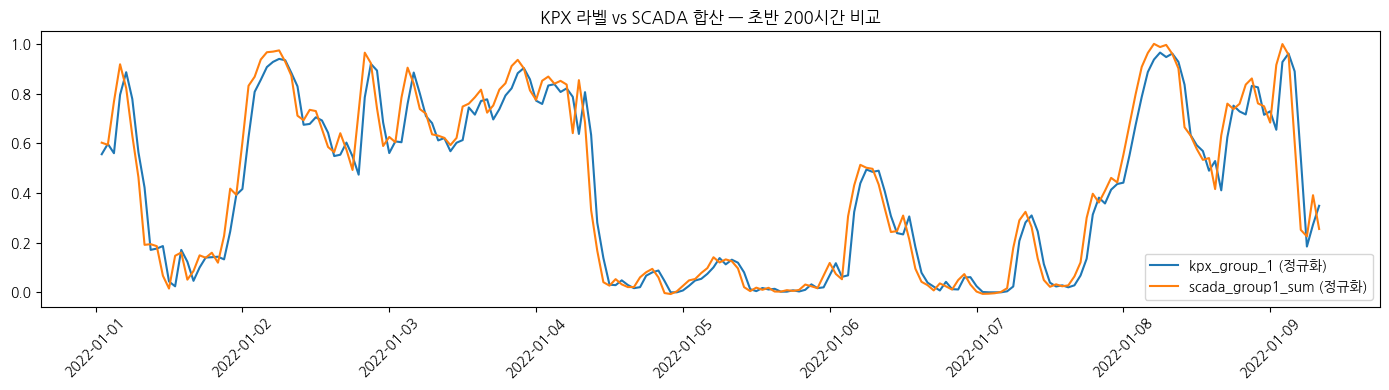

In [23]:
sample_period = overlap.iloc[:200]
plt.figure(figsize=(14, 4))
plt.plot(sample_period["forecast_kst_dtm"], sample_period["kpx_group_1"] / 21600, label="kpx_group_1 (정규화)")
plt.plot(sample_period["forecast_kst_dtm"], sample_period["scada_group1_sum"] / sample_period["scada_group1_sum"].max(), label="scada_group1_sum (정규화)")
plt.legend()
plt.title("KPX 라벨 vs SCADA 합산 — 초반 200시간 비교")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
CAPACITY_PER_TURBINE_KW = 3600

vestas_power_cols = [c for c in scada_vestas.columns if "power" in c]
scada_vestas_clean = scada_vestas.copy()

for col in vestas_power_cols:
    before_valid = scada_vestas_clean[col].between(-100, CAPACITY_PER_TURBINE_KW * 1.2).sum()
    scada_vestas_clean.loc[
        ~scada_vestas_clean[col].between(-100, CAPACITY_PER_TURBINE_KW * 1.2), col
    ] = np.nan
    print(f"{col}: 정상 범위 내 값 {before_valid}/{len(scada_vestas_clean)} ({before_valid/len(scada_vestas_clean):.1%})")

vestas_wtg01_power_kw10m: 정상 범위 내 값 157745/157819 (100.0%)
vestas_wtg02_power_kw10m: 정상 범위 내 값 157749/157819 (100.0%)
vestas_wtg03_power_kw10m: 정상 범위 내 값 157731/157819 (99.9%)
vestas_wtg04_power_kw10m: 정상 범위 내 값 157775/157819 (100.0%)
vestas_wtg05_power_kw10m: 정상 범위 내 값 157747/157819 (100.0%)
vestas_wtg06_power_kw10m: 정상 범위 내 값 157759/157819 (100.0%)
vestas_wtg07_power_kw10m: 정상 범위 내 값 157751/157819 (100.0%)
vestas_wtg08_power_kw10m: 정상 범위 내 값 157717/157819 (99.9%)
vestas_wtg09_power_kw10m: 정상 범위 내 값 157767/157819 (100.0%)
vestas_wtg10_power_kw10m: 정상 범위 내 값 157751/157819 (100.0%)
vestas_wtg11_power_kw10m: 정상 범위 내 값 157721/157819 (99.9%)
vestas_wtg12_power_kw10m: 정상 범위 내 값 157747/157819 (100.0%)


In [25]:
vestas_hourly_clean = scada_vestas_clean.set_index("kst_dtm").resample("h").mean()

In [26]:
for i in range(1, 13):
    col = f"vestas_wtg{i:02d}_power_kw10m"
    if col not in vestas_hourly_clean.columns:
        continue
    merged = df[["forecast_kst_dtm", "kpx_group_1", "kpx_group_2"]].merge(
        vestas_hourly_clean[[col]].reset_index().rename(columns={"kst_dtm": "forecast_kst_dtm"}),
        on="forecast_kst_dtm", how="inner"
    ).dropna()
    corr1 = merged[[col, "kpx_group_1"]].corr().iloc[0, 1]
    corr2 = merged[[col, "kpx_group_2"]].corr().iloc[0, 1]
    print(f"{col}: vs group1={corr1:.3f}, vs group2={corr2:.3f}")

vestas_wtg01_power_kw10m: vs group1=0.885, vs group2=0.838
vestas_wtg02_power_kw10m: vs group1=0.911, vs group2=0.886
vestas_wtg03_power_kw10m: vs group1=0.925, vs group2=0.908
vestas_wtg04_power_kw10m: vs group1=0.887, vs group2=0.864
vestas_wtg05_power_kw10m: vs group1=0.820, vs group2=0.778
vestas_wtg06_power_kw10m: vs group1=0.889, vs group2=0.869
vestas_wtg07_power_kw10m: vs group1=0.849, vs group2=0.869
vestas_wtg08_power_kw10m: vs group1=0.894, vs group2=0.928
vestas_wtg09_power_kw10m: vs group1=0.888, vs group2=0.936
vestas_wtg10_power_kw10m: vs group1=0.895, vs group2=0.933
vestas_wtg11_power_kw10m: vs group1=0.869, vs group2=0.907
vestas_wtg12_power_kw10m: vs group1=0.866, vs group2=0.907


In [27]:
group1_turbines_confirmed = [f"vestas_wtg{i:02d}_power_kw10m" for i in range(1, 7)]
group2_turbines_confirmed = [f"vestas_wtg{i:02d}_power_kw10m" for i in range(7, 13)]

scada_group_sum_v2 = pd.DataFrame(index=vestas_hourly_clean.index)
scada_group_sum_v2["scada_group1_sum"] = vestas_hourly_clean[group1_turbines_confirmed].sum(axis=1)
scada_group_sum_v2["scada_group2_sum"] = vestas_hourly_clean[group2_turbines_confirmed].sum(axis=1)
scada_group_sum_v2 = scada_group_sum_v2.reset_index().rename(columns={"kst_dtm": "forecast_kst_dtm"})

check_v2 = df.merge(scada_group_sum_v2, on="forecast_kst_dtm", how="inner")
for i in [1, 2]:
    col = f"kpx_group_{i}"
    scada_col = f"scada_group{i}_sum"
    corr = check_v2[[scada_col, col]].dropna().corr().iloc[0, 1]
    print(f"{col} vs {scada_col} 최종 상관계수: {corr:.4f}")

kpx_group_1 vs scada_group1_sum 최종 상관계수: 0.9654
kpx_group_2 vs scada_group2_sum 최종 상관계수: 0.9688
